In [1]:
import os
os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=8'
import argparse
from pathlib import Path
from jax import config, local_device_count, device_count
import jax.numpy as np
from jax.scipy.stats import norm
from jax.lax import integer_pow, broadcast_in_dim
config.update("jax_enable_x64", True)

import numpy as onp
import matplotlib.pyplot as plt

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MTSUN_SI, DAY_TO_SEC
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
import gwfast.network as network
from gwfast.signals import AGNLensedGWSignal, GeneralLensedGWSignal
from gwfast.lensing_utils import compute_lensed_angles_approx
from gwfast.fisherTools import (
    reduce_Fisher_matrix, 
    compute_covariance_matrix, 
    covariance_change_variable
)

/users/hin-wai.leong/src/AGN-gwfast/gwfast/waveforms.py:35: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [2]:
local_device_count(), device_count()

(8, 8)

In [2]:
def convert_y_from_Einstein_to_Rorbit(y_Eins, r_orbit):
    kappa = y_Eins*y_Eins / r_orbit
    return np.sqrt(2 * kappa * (np.sqrt(1 + kappa*kappa) - kappa))

## 1. Use AGN model

In [3]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

H1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_Lensed = network.DetNet({'H1': H1_Lensed, 'L1': L1_Lensed, 'V1': V1_Lensed})


Initializing jax...
Jax local device count: 8
Jax device count: 8
Initializing jax...
Jax local device count: 8
Jax device count: 8
Initializing jax...
Jax local device count: 8
Jax device count: 8
Initializing jax...
Jax local device count: 8
Jax device count: 8
Initializing jax...
Jax local device count: 8
Jax device count: 8
Initializing jax...
Jax local device count: 8
Jax device count: 8


In [5]:
n_D = 5
n_y = 3
n_R = 3

shape = (n_D, n_y, n_R)
# TODO: Revisit these parameters
lensing_parameters = {
    'Mc': 30, 'eta': 0.24, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.5,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}
lensing_parameters = {key: np.full(shape, val).astype(np.float64) for key, val in lensing_parameters.items()}

# Sample parameter space
dL_array = np.flip(np.geomspace(0.2, 2, n_D)) # Gpc
y_Eins_array = np.linspace(0.2, 1, n_y) # in Einstein radii
R_orbit_array = np.linspace(10, 1000, n_R)

dL_mesh, R_orbit_mesh, y_Eins_mesh = np.meshgrid(
    dL_array, R_orbit_array, y_Eins_array, indexing='ij')
lensing_parameters['dL'] = dL_mesh
lensing_parameters['R_orbit'] = R_orbit_mesh
y_Rorbit = convert_y_from_Einstein_to_Rorbit(y_Eins_mesh, R_orbit_mesh)
lensing_parameters['src_pos'] = y_Rorbit

Computing Fisher for H1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.892039703874381, Maximum duration: 12.26620066992932.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 8.55430165083849, Maximum duration: 12.26620066992932.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 9.17036210664171, Maximum duration: 12.26620066992932.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 12.26620066992932.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum dura

/users/hin-wai.leong/.conda/envs/180125_py311_AGNLensing/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


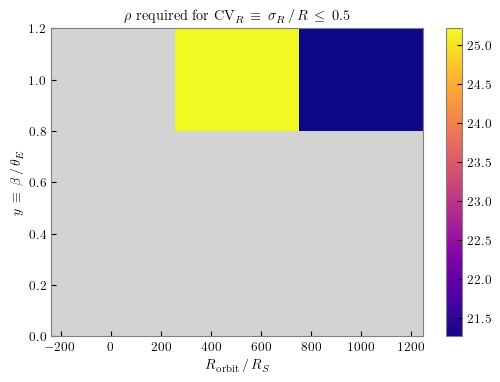

In [6]:
CV_R_threshold = 0.5
fisher_matrix = HLV_AGN.FisherMatr(lensing_parameters, res=500)
covar_matrix, _ = compute_covariance_matrix(fisher_matrix)

# Version 1? 
# Use R_orb as the threshold
key_variable = 'R_orbit'
parameter_keys = list(lensing_parameters.keys())
key_idx = parameter_keys.index(key_variable)
std = onp.sqrt(covar_matrix[key_idx, key_idx])
coeff_var = std / onp.asarray(lensing_parameters['R_orbit'])
threshold = 0.5
mask = coeff_var <= threshold
passes = np.asarray(onp.diff(mask, axis=0))

masked_lensing_parameters = {key: val[1:, :, :][passes] for key, val in lensing_parameters.items()}

snr_grid = np.zeros_like(dL_mesh[1, :, :])
snr_grid = snr_grid.at[np.any(passes, axis=0)].set(HLV_AGN.SNR(masked_lensing_parameters, res=1000))
snr_masked_grid = onp.ma.masked_where(snr_grid == 0, snr_grid)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
cmap = plt.cm.plasma
cmap.set_bad(color='lightgrey')

im = ax.pcolormesh(R_orbit_array, y_Eins_array, snr_masked_grid, cmap=cmap)
fig.colorbar(im, ax=ax)
ax.set_xlabel(r'$R_{\rm orbit}\,/\,R_S$')
ax.set_ylabel(r'$y\,\equiv\,\beta\,/\,\theta_E$')
ax.set_title(r'$\rho$ required for ${\rm CV}_R\,\equiv\,\sigma_R\,/\,R\,\leq\,0.5$')
fig.savefig('Test.pdf')

### 1.a Convert with Jacobian

In [86]:
snr_grid

Array([[44.38375203, 28.96675286, 26.14075367],
       [25.24463767, 21.30155021, 44.84126908],
       [67.2304798 ,         nan,         nan]], dtype=float64)

[[[False False False]
  [False  True  True]
  [False False False]]

 [[False False False]
  [False False False]
  [False  True False]]

 [[False False False]
  [False False False]
  [False False  True]]

 [[False False False]
  [False False False]
  [False False False]]]
[[[ True  True  True]
  [False  True  True]
  [False False False]]

 [[False False False]
  [False False False]
  [False  True False]]

 [[False False False]
  [False False False]
  [False False  True]]

 [[False False False]
  [ True False False]
  [ True False False]]]
[44.38375203 28.96675286 26.14075367 25.24463767 21.30155021 44.84126908
 67.2304798          nan         nan]


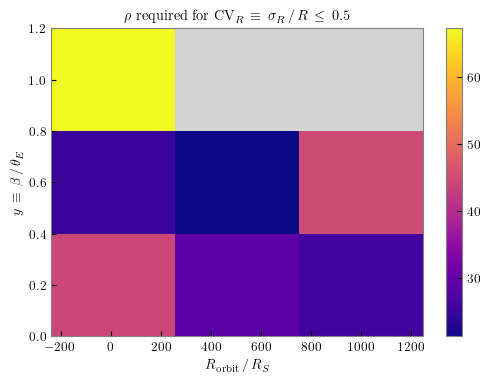

In [90]:
# Option 1:
## Convert the `covar_matrix` to the generic parameters

def lensing_transform(lensing_parameters):
    # A fiducial phase which does not affect the Jacobian results
    lensing_parameters['phase'] = 0.0
    lensing_parameters['psi'] = 0.0
    outputs = compute_lensed_angles_approx(lensing_parameters)
    phenom_changes = {}
    phenom_changes['delta_iota'] = outputs['iota_m'] - outputs['iota_p']
    phenom_changes['delta_phi'] = outputs['phase_m'] - outputs['phase_p']

    # (Radial gravitational potential is cancelled)
    phenom_changes['relative_mass'] = (1 + outputs['z_rel_m']) / (1 + outputs['z_rel_p'])
    relative_magification = outputs['sqrt_mu_p'] / outputs['sqrt_mu_m']
    phenom_changes['relative_distance'] = relative_magification * integer_pow((1 + outputs['z_rel_m']) / (1 + outputs['z_rel_p']), 2)
    phenom_changes['delta_time'] = outputs['delta_time']
    return phenom_changes

from_params = ['iota', 'R_orbit', 'src_pos', 'M_lz', 'dL']
transformed_cov_mat, transformed_parameters, transformed_keys = covariance_change_variable(
    covar_matrix, lensing_parameters, lensing_transform, from_params
)

# Version 1.1? 
# Use R_orb as the threshold
key_variable = 'relative_mass'
key_idx = transformed_keys.index(key_variable)
std = onp.sqrt(transformed_cov_mat[key_idx, key_idx], dtype='float64')
mean = transformed_parameters['relative_mass']
p_val = norm.pdf(1, loc=mean, scale=std)
threshold = 0.1
mask = p_val <= threshold
passes = np.asarray(onp.diff(mask, axis=0))
print(passes)
all_pass = np.all(mask, axis=0)
passes = passes.at[0, all_pass].set(True)
all_fail = np.all(~mask, axis=0)
passes = passes.at[-1, all_fail].set(True)
print(passes)

masked_lensing_parameters = {key: val[1:, :, :][passes] for key, val in lensing_parameters.items()}

snr_grid = np.zeros_like(dL_mesh[1, :, :])
snr_grid = snr_grid.at[np.any(passes, axis=0)].set(HLV_AGN.SNR(masked_lensing_parameters, res=1000))
snr_masked_grid = onp.ma.masked_where(snr_grid == 0, snr_grid)

print(HLV_AGN.SNR(masked_lensing_parameters, res=1000))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
cmap = plt.cm.plasma
cmap.set_bad(color='lightgrey')

im = ax.pcolormesh(R_orbit_array, y_Eins_array, snr_masked_grid, cmap=cmap)
fig.colorbar(im, ax=ax)
ax.set_xlabel(r'$R_{\rm orbit}\,/\,R_S$')
ax.set_ylabel(r'$y\,\equiv\,\beta\,/\,\theta_E$')
ax.set_title(r'$\rho$ required for ${\rm CV}_R\,\equiv\,\sigma_R\,/\,R\,\leq\,0.5$')
fig.savefig('Test_2.pdf')

In [80]:
np.any(passes, axis=0)

Array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]], dtype=bool)

## 2. Use generic model

In [42]:
H1_lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_lensed = network.DetNet({'H1': H1_lensed, 'L1': L1_lensed, 'V1': V1_lensed})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: [2.76161987], Maximum duration: [0.25140763].

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 2.7616198677010635, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 2.7616198677010635, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: [2.76161987], Maximum duration: [0.25140763].

Warnin

In [52]:
model_parameters = L1_AGN.convert_to_general_lensed_parameters(lensing_parameters)
keys = list(model_parameters.keys()).copy()

lensed_HLV_fisher = HLV_lensed.FisherMatr(model_parameters, res=1000)

# If some of the events is nan, then the reduce matrix won't work
cleaned_lensed_HLV_fisher = np.nan_to_num(lensed_HLV_fisher, nan=0.0)

lensed_fisher_mat, rm_keys = reduce_Fisher_matrix(cleaned_lensed_HLV_fisher, keys=keys)
print(rm_keys)
lensed_fisher_mat[lensed_fisher_mat == 0.0] = np.nan
lensed_cov_mats, ie = compute_covariance_matrix(lensed_fisher_mat)

Computing Fisher for H1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.892039703874381, Maximum duration: 23.702200992227855.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 8.55430165083849, Maximum duration: 23.45269477681311.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 9.17036210664171, Maximum duration: 23.245644880921507.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: nan.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolve

/users/hin-wai.leong/.conda/envs/180125_py311_AGNLensing/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


[[ True  True  True]
 [ True  True  True]
 [ True  True  True]]


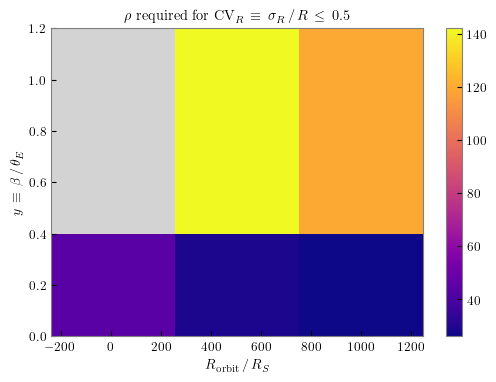

In [88]:
key_variable = 'relative_mass'
parameter_keys = list(model_parameters.keys())
key_idx = transformed_keys.index(key_variable)
std = onp.sqrt(lensed_cov_mats[key_idx, key_idx], dtype='float64')
mean = model_parameters['relative_mass']
p_val = norm.pdf(1, loc=mean, scale=std)
threshold = 0.1
mask = p_val <= threshold
passes = np.asarray(onp.diff(mask, axis=0))
all_pass = np.all(mask, axis=0)
passes = passes.at[0, all_pass].set(True)
all_fail = np.all(~mask, axis=0)
passes = passes.at[-1, all_fail].set(True)

masked_lensing_parameters = {key: val[1:, :, :][passes] for key, val in model_parameters.items()}
snr_grid = np.zeros_like(dL_mesh[1, :, :])
snr_grid = snr_grid.at[np.any(passes, axis=0)].set(HLV_lensed.SNR(masked_lensing_parameters, res=1000))
snr_masked_grid = onp.ma.masked_where(snr_grid == 0, snr_grid)

print(np.any(passes, axis=0))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
cmap = plt.cm.plasma
cmap.set_bad(color='lightgrey')

im = ax.pcolormesh(R_orbit_array, y_Eins_array, snr_masked_grid, cmap=cmap)
fig.colorbar(im, ax=ax)
ax.set_xlabel(r'$R_{\rm orbit}\,/\,R_S$')
ax.set_ylabel(r'$y\,\equiv\,\beta\,/\,\theta_E$')
ax.set_title(r'$\rho$ required for ${\rm CV}_R\,\equiv\,\sigma_R\,/\,R\,\leq\,0.5$')
fig.savefig('Test_3.pdf')

## 3. Scale up with multi-processing

In [15]:
def Jacobian_covariance(lensing_parameters):
    # 4.b Compute the Fisher
    fisher_matrix = HLV_AGN.FisherMatr(lensing_parameters, res=100)
    # 4.c Reduce and compute covar
    covar_matrix, _ = compute_covariance_matrix(fisher_matrix)

    from_params = ['iota', 'R_orbit', 'src_pos', 'M_lz', 'dL']
    transformed_cov_mat, transformed_parameters, transformed_keys = covariance_change_variable(
        covar_matrix, lensing_parameters, lensing_transform, from_params
    )
    print(transformed_parameters)
    return transformed_cov_mat, transformed_parameters, transformed_keys


def direct_covariance(lensing_parameters):
    model_parameters = L1_AGN.convert_to_general_lensed_parameters(lensing_parameters)
    keys = list(model_parameters.keys()).copy()

    lensed_HLV_fisher = HLV_lensed.FisherMatr(model_parameters, res=1000)

    # If some of the events is nan, then the reduce matrix won't work
    cleaned_lensed_HLV_fisher = np.nan_to_num(lensed_HLV_fisher, nan=0.0)

    lensed_fisher_mat, rm_keys = reduce_Fisher_matrix(cleaned_lensed_HLV_fisher, keys=keys)
    print(rm_keys)
    lensed_fisher_mat[lensed_fisher_mat == 0.0] = np.nan
    lensed_cov_mats, _ = compute_covariance_matrix(lensed_fisher_mat)
    return lensed_cov_mats, model_parameters, keys


def lensing_transform(lensing_parameters):
    # A fiducial phase which does not affect the Jacobian results
    lensing_parameters['phase'] = 0.0
    lensing_parameters['psi'] = 0.0
    outputs = compute_lensed_angles_approx(lensing_parameters)
    phenom_changes = {}
    phenom_changes['delta_iota'] = outputs['iota_m'] - outputs['iota_p']
    phenom_changes['delta_phi'] = outputs['phase_m'] - outputs['phase_p']

    # (Radial gravitational potential is cancelled)
    phenom_changes['relative_mass'] = (1 + outputs['z_rel_m']) / (1 + outputs['z_rel_p'])
    relative_magification = outputs['sqrt_mu_p'] / outputs['sqrt_mu_m']
    phenom_changes['relative_distance'] = relative_magification * integer_pow((1 + outputs['z_rel_m']) / (1 + outputs['z_rel_p']), 2)
    phenom_changes['delta_time'] = outputs['delta_time']
    return phenom_changes

In [57]:
n_y = 10
n_R = 10

reference_parameters = {
    'Mc': 30, 'eta': 0.24, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.5,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}

# 1. Prepare matrix of (y, R)
y_Eins_array = np.linspace(0.2, 1, n_y) # in Einstein radii
R_orbit_array = np.linspace(10, 1000, n_R)
R_orbit_mesh, y_Eins_mesh = np.meshgrid(R_orbit_array, y_Eins_array, indexing='ij')
y_Rorbit_mesh = convert_y_from_Einstein_to_Rorbit(y_Eins_mesh, R_orbit_array)
# 2. Flatten it
Ry_tuple_list = np.vstack([R_orbit_mesh.flatten(), y_Rorbit_mesh.flatten()]).T
# 3. Split it
# 4. Enters the function
def worker(Ry_tuple_sublist, n_D, model='agn'):
    R_list = Ry_tuple_sublist[:, 0]
    y_list = Ry_tuple_sublist[:, 1]
    input_len = Ry_tuple_sublist.shape[0]
    shape = (input_len, n_D)
    lensing_parameters = {key: np.full(shape, val).astype(np.float64) for key, val in reference_parameters.items()}
    D_array = np.flip(np.geomspace(0.1, 2, n_D))
    # 4.a Expand the dimension
    R_mesh, D_mesh = np.meshgrid(R_list, D_array, indexing='ij')
    y_mesh, D_mesh_2 = np.meshgrid(y_list, D_array, indexing='ij')
    assert np.all(D_mesh == D_mesh_2)
    lensing_parameters['R_orbit'] = R_mesh
    lensing_parameters['src_pos'] = y_mesh
    lensing_parameters['dL'] = D_mesh

    if model == 'agn':
        covar_func = Jacobian_covariance
        network = HLV_AGN
    elif model == 'generic':
        covar_func = direct_covariance
        network = HLV_Lensed
    covariance_mat, params_dict, keys = covar_func(lensing_parameters)

    # 4.d Compute the threshold
    key_variable = 'relative_mass'
    key_idx = keys.index(key_variable)
    std = onp.sqrt(covariance_mat[key_idx, key_idx], dtype='float64')
    mean = params_dict['relative_mass']
    p_val = norm.pdf(1, loc=mean, scale=std)
    threshold = 0.1
    mask = p_val <= threshold
    passes = np.asarray(onp.diff(mask, axis=1))
    passes_idx = np.argwhere(passes)
    passes_idx = passes_idx.at[:, 1].add(1)
    all_pass_idx = np.argwhere(np.all(mask, axis=1))
    passes_idx = np.concatenate(
        (passes_idx, np.hstack((all_pass_idx, np.zeros_like(all_pass_idx)))), 
        axis=0
    ).T
    row_idx = passes_idx[0]

    # 4.e Pick out the distance and join into (y, R, D) form
    tuple_list = np.full((input_len, 3), np.nan)
    tuple_arr = np.array([
            R_list[row_idx], y_list[row_idx], 
            D_mesh[passes_idx[0], passes_idx[1]]
        ]).T
    print(tuple_arr)
    tuple_list = tuple_list.at[row_idx].set(tuple_arr)

    # 4.e Pack into the parameter dictionary
    masked_parameters = {key: val[:, 0] for key, val in lensing_parameters.items()}
    masked_parameters['R_orbit'] = tuple_list.T[0]
    masked_parameters['src_pos'] = tuple_list.T[1]
    masked_parameters['dL'] = tuple_list.T[2]

    # 4.e Compute SNR and returns
    return network.SNR(masked_parameters, res=1000)

# 5. Convert the overall result into a single matrix
# 6. Plot

In [ ]:
worker(Ry_tuple_list, n_D=10, model='agn')

Computing Fisher for H1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.892039703874381, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.89617665294146, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.899762444751147, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.9027739530336305, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than 

In [ ]:
_48 

array([ 24.95778297,  31.45492933,  28.3800578 ,  26.37650042,
        24.95778297,  11.97594408,  13.80136726,  12.91500496,
        12.35258778,  11.97594408,  49.68726597,  26.00377255,
        24.73004518,  23.97448892,  49.68726597, 102.06073333,
        52.10218413,  50.09063179,  48.95271772, 102.06073333,
       100.5115453 ,  50.49423256, 103.44898801, 101.64284531,
       100.5115453 ])

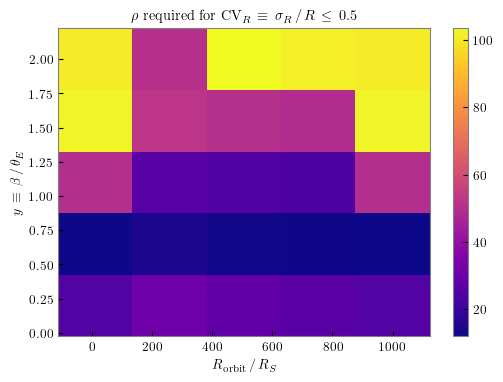

In [54]:
snr_grid = np.reshape(_48, (5, 5))


fig, ax = plt.subplots(1, 1, figsize=(6, 4))
cmap = plt.cm.plasma
cmap.set_bad(color='lightgrey')

im = ax.pcolormesh(R_orbit_array, y_Eins_array, snr_grid, cmap=cmap)
fig.colorbar(im, ax=ax)
ax.set_xlabel(r'$R_{\rm orbit}\,/\,R_S$')
ax.set_ylabel(r'$y\,\equiv\,\beta\,/\,\theta_E$')
ax.set_title(r'$\rho$ required for ${\rm CV}_R\,\equiv\,\sigma_R\,/\,R\,\leq\,0.5$')
fig.savefig('Test_2.pdf')

In [40]:
arr_2d = np.arange(10).reshape(5,2)

indices = np.argwhere(arr_2d > 5).T
arr_2d[indices[0], indices[1]]

Array([6, 7, 8, 9], dtype=int64)

In [38]:
indices

Array([[3, 3, 4, 4],
       [0, 1, 0, 1]], dtype=int64)

In [34]:
np.choose(arr_2d, indices)

ValueError: invalid entry in choice array

In [24]:
np.arange(10)[np.array([0, 2, 3])]

Array([0, 2, 3], dtype=int64)

## Let's try a new criteria

The effect is "detectable" if 0 is lying outside of the $3\sigma$ region of $p(\ln(\eta_{\cal M}))$.

In [6]:
n_y = 10
n_R = 50

reference_parameters = {
    'Mc': 30, 'eta': 0.24, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.5,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}

# 1. Prepare matrix of (y, R)
y_Eins_array = np.linspace(0.2, 1, n_y) # in Einstein radii
R_orbit_array = np.linspace(10, 1000, n_R)
R_orbit_mesh, y_Eins_mesh = np.meshgrid(R_orbit_array, y_Eins_array, indexing='ij')
y_Rorbit_mesh = convert_y_from_Einstein_to_Rorbit(y_Eins_mesh, R_orbit_mesh)
# 2. Flatten it
Ry_tuple_list = np.vstack([R_orbit_mesh.flatten(), y_Rorbit_mesh.flatten()]).T
# 3. Split it
# 4. Enters the function
def worker(Ry_tuple_sublist, model='agn', check=False):
    input_len = Ry_tuple_sublist.shape[0]
    shape = (input_len)
    lensing_parameters = {key: np.full(shape, val).astype(np.float64) for key, val in reference_parameters.items()}
    lensing_parameters['R_orbit'] = Ry_tuple_sublist[:, 0]
    lensing_parameters['src_pos'] = Ry_tuple_sublist[:, 1]

    if model == 'agn':
        covar_func = Jacobian_covariance
        network = HLV_AGN
    elif model == 'generic':
        covar_func = direct_covariance
        network = HLV_Lensed
    covariance_mat, params_dict, keys = covar_func(lensing_parameters)

    # 4.d Compute the threshold
    key_variable = 'relative_mass'
    key_idx = keys.index(key_variable)
    std = onp.sqrt(covariance_mat[key_idx, key_idx], dtype='float64')
    mean = params_dict['relative_mass']
    ln_mean = np.log(mean)
    std_ln = std / mean
    target_std = np.abs((ln_mean - 0))/ 3
    scale = std_ln / target_std

    # Compute the original SNR
    orig_snr = network.SNR(lensing_parameters, res=1000)
    result_snr = orig_snr / scale

    if check:
        new_lensing_parameters = lensing_parameters.copy()
        new_lensing_parameters['dL'] *= scale
        new_covariance_mat, _, _ = covar_func(new_lensing_parameters)
        new_std = onp.sqrt(new_covariance_mat[key_idx, key_idx], dtype='float64')
        frac = 1 - new_std / target_std
        print(f'New v.s. target: ', frac)

    # 4.e Compute SNR and returns
    return result_snr

# 5. Convert the overall result into a single matrix
# 6. Plot

In [16]:
n_y = 4
n_R = 4

reference_parameters = {
    'Mc': 30, 'eta': 0.24, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.5,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}

# 1. Prepare matrix of (y, R)
y_Eins_array = np.linspace(0.2, 1, n_y) # in Einstein radii
R_orbit_array = np.linspace(10, 1000, n_R)
R_orbit_mesh, y_Eins_mesh = np.meshgrid(R_orbit_array, y_Eins_array, indexing='xy')
y_Rorbit_mesh = convert_y_from_Einstein_to_Rorbit(y_Eins_mesh, R_orbit_mesh)
# 2. Flatten it
Ry_tuple_list = np.vstack([R_orbit_mesh.flatten(), y_Rorbit_mesh.flatten()]).T

snr_list = worker(Ry_tuple_list, model='agn')

Computing Fisher for H1...
Computing Fisher for L1...
Computing Fisher for V1...
Done.


/users/hin-wai.leong/.conda/envs/180125_py311_AGNLensing/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


{'Mc': Array([30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.,
       30., 30., 30.], dtype=float64), 'eta': Array([0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.24,
       0.24, 0.24, 0.24, 0.24, 0.24], dtype=float64), 'delta_iota': Array([0.15677868,        nan,        nan,        nan, 0.06659632,
       0.06730382, 0.06731444, 0.06731805, 0.0417073 , 0.04280955,
       0.04282623, 0.04283191, 0.02988869, 0.03137234, 0.03139507,
       0.03140281], dtype=float64), 'phase': Array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],      dtype=float64), 'chi1z': Array([0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3,
       0.3, 0.3, 0.3], dtype=float64), 'chi2z': Array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5], dtype=float64), 'tcoal': Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float64), 'delta_phi': Array([0.88068826,        nan,        na

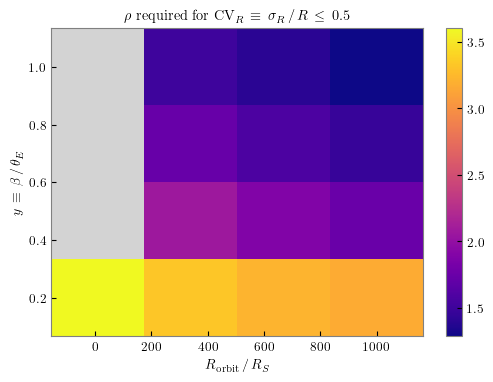

In [17]:
snr_grid = np.reshape(snr_list, (n_R, n_y))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
cmap = plt.cm.plasma
cmap.set_bad(color='lightgrey')

im = ax.pcolormesh(R_orbit_array, y_Eins_array, np.log10(snr_grid.T), cmap=cmap)
fig.colorbar(im, ax=ax)
ax.set_xlabel(r'$R_{\rm orbit}\,/\,R_S$')
ax.set_ylabel(r'$y\,\equiv\,\beta\,/\,\theta_E$')
ax.set_title(r'$\rho$ required for ${\rm CV}_R\,\equiv\,\sigma_R\,/\,R\,\leq\,0.5$')
fig.savefig('Test_2.pdf')

Text(0.5, 1.0, 'Change in relative masses')

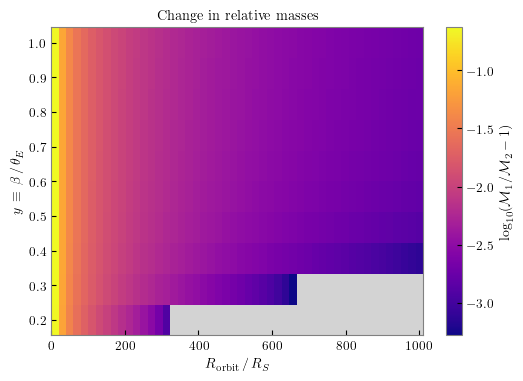

In [20]:
n_y = 10
n_R = 50

# 1. Prepare matrix of (y, R)
y_Eins_array = np.linspace(0.2, 1, n_y) # in Einstein radii
R_orbit_array = np.linspace(10, 1000, n_R)
R_orbit_mesh, y_Eins_mesh = np.meshgrid(R_orbit_array, y_Eins_array, indexing='xy')
y_Rorbit_mesh = convert_y_from_Einstein_to_Rorbit(y_Eins_mesh, R_orbit_mesh)
# 2. Flatten it
Ry_tuple_list = np.vstack([R_orbit_mesh.flatten(), y_Rorbit_mesh.flatten()]).T

from_params = ['iota', 'R_orbit', 'src_pos', 'M_lz', 'dL']
ref_params = {
    'iota': 0.99 * np.pi / 2, 
    'R_orbit': 1.,
    'src_pos': 0.1,
    'M_lz': 1e5,
    'dL': 100
}
shape = Ry_tuple_list.shape[0]
input_params = {key: np.full(shape, val).astype(np.float64) for key, val in ref_params.items()}
input_params['R_orbit'] = Ry_tuple_list[:, 0]
input_params['src_pos'] = Ry_tuple_list[:, 1]

output_params = lensing_transform(input_params)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

im = ax.pcolormesh(R_orbit_array, y_Eins_array, np.log10(output_params['relative_mass'].reshape(10,50)-1), cmap=cmap)
fig.colorbar(im, ax=ax, label=r'$\log_{10}({\cal M}_1/{\cal M}_2 - 1)$')
ax.set_xlabel(r'$R_{\rm orbit}\,/\,R_S$')
ax.set_ylabel(r'$y\,\equiv\,\beta\,/\,\theta_E$')
ax.set_title(r'Change in relative masses')
# fig.savefig('Test_2.pdf')


In [19]:
from_params = ['iota', 'R_orbit', 'src_pos', 'M_lz', 'dL']
ref_params = {
    'iota': 0.99 * np.pi / 2, 
    'R_orbit': 800.,
    'src_pos': convert_y_from_Einstein_to_Rorbit(0.1, 100),
    'M_lz': 1e5,
    'dL': 100
}
# shape = Ry_tuple_list.shape[0]
# input_params = {key: np.full(shape, val).astype(np.float64) for key, val in ref_params.items()}
# input_params['R_orbit'] = Ry_tuple_list[:, 0]
# input_params['src_pos'] = Ry_tuple_list[:, 1]

output_params = lensing_transform(ref_params)
output_params
# fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# im = ax.pcolormesh(R_orbit_array, y_Eins_array, np.log10(output_params['relative_mass'].reshape(10,50)-1), cmap=cmap)
# fig.colorbar(im, ax=ax, label=r'$\log_{10}({\cal M}_1/{\cal M}_2 - 1)$')
# ax.set_xlabel(r'$R_{\rm orbit}\,/\,R_S$')
# ax.set_ylabel(r'$y\,\equiv\,\beta\,/\,\theta_E$')
# ax.set_title(r'Change in relative masses')
# # fig.savefig('Test_2.pdf')


{'delta_iota': Array(nan, dtype=float64),
 'delta_phi': Array(nan, dtype=float64),
 'relative_mass': Array(nan, dtype=float64),
 'relative_distance': Array(nan, dtype=float64),
 'delta_time': Array(-0.10649667, dtype=float64)}

In [1]:
jax.local_device_count()

NameError: name 'jax' is not defined

$$
d_{\rm LS}^2 = r_{\rm orbit}^2 (1 + y^2)
$$

$$
d_{\rm LS} = D_{\rm LS} \,/\,R_{\rm Sch} \quad\text{and}\quad
r_{\rm orbit} = R_{\rm orbit} \,/\,R_{\rm Sch}
$$

$$
y^2 = 2 \kappa (\sqrt{1 + \kappa^2} + \kappa)
$$

$y$: in units of $R_{\rm orbit}$
$$
\kappa \equiv y_{\rm Ein}^2\,/\,r_{\rm orbit}
$$

## Test the generic model

In [6]:
n_y = 3
n_R = 3

shape = (n_y, n_R)
# TODO: Revisit these parameters
lensing_parameters = {
    'Mc': 30, 'eta': 0.24, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.5,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}
lensing_parameters = {key: np.full(shape, val).astype(np.float64) for key, val in lensing_parameters.items()}

# Sample parameter space
y_Eins_array = np.linspace(0.1, 1, n_y) # in Einstein radii
R_orbit_array = np.linspace(10, 1000, n_R)

R_orbit_mesh, y_Eins_mesh = np.meshgrid(
    R_orbit_array, y_Eins_array, indexing='xy')
lensing_parameters['R_orbit'] = R_orbit_mesh
y_Rorbit = convert_y_from_Einstein_to_Rorbit(y_Eins_mesh, R_orbit_mesh)
lensing_parameters['src_pos'] = y_Rorbit

In [5]:
def direct_covariance(lensing_parameters):
    model_parameters = L1_AGN.convert_to_general_lensed_parameters(lensing_parameters)
    keys = list(model_parameters.keys()).copy()

    lensed_HLV_fisher = HLV_Lensed.FisherMatr(model_parameters, res=200)

    # If some of the events is nan, then the reduce matrix won't work
    cleaned_lensed_HLV_fisher = np.nan_to_num(lensed_HLV_fisher, nan=0.0)

    lensed_fisher_mat, rm_keys = reduce_Fisher_matrix(cleaned_lensed_HLV_fisher, keys=keys)
    print(rm_keys)
    lensed_fisher_mat[lensed_fisher_mat == 0.0] = np.nan
    lensed_cov_mats, _ = compute_covariance_matrix(lensed_fisher_mat, cores=1)
    return lensed_cov_mats, model_parameters, keys

In [8]:
direct_covariance(lensing_parameters), 

Computing Fisher for H1...


KeyboardInterrupt: 

In [11]:
model_parameters = L1_AGN.convert_to_general_lensed_parameters(lensing_parameters)
HLV_Lensed.SNR(model_parameters, res=1000)

array([[72.78181591,         nan,         nan],
       [33.40014166, 29.39811067, 29.36620646],
       [29.40004737, 23.95762836, 23.91238299]])

In [10]:
lensing_parameters

{'Mc': Array([[30., 30., 30.],
        [30., 30., 30.],
        [30., 30., 30.]], dtype=float64),
 'eta': Array([[0.24, 0.24, 0.24],
        [0.24, 0.24, 0.24],
        [0.24, 0.24, 0.24]], dtype=float64),
 'iota': Array([[1.55508836, 1.55508836, 1.55508836],
        [1.55508836, 1.55508836, 1.55508836],
        [1.55508836, 1.55508836, 1.55508836]], dtype=float64),
 'phase': Array([[2., 2., 2.],
        [2., 2., 2.],
        [2., 2., 2.]], dtype=float64),
 'chi1z': Array([[0.3, 0.3, 0.3],
        [0.3, 0.3, 0.3],
        [0.3, 0.3, 0.3]], dtype=float64),
 'chi2z': Array([[0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]], dtype=float64),
 'tcoal': Array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=float64),
 'R_orbit': Array([[  10.,  505., 1000.],
        [  10.,  505., 1000.],
        [  10.,  505., 1000.]], dtype=float64),
 'M_lz': Array([[10000., 10000., 10000.],
        [10000., 10000., 10000.],
        [10000., 10000., 10000.]], dtype=float64